## CA 1, LLMs Spring 2025

- **Name:** Erfan Shahabi

---
#### Your submission should be named using the following format: `CA1_LASTNAME_STUDENTID.ipynb`.

---

##### *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says ```Your Answer Here``` with your actual answer.

- There is no penalty for using AI assistance on this homework as long as you fully disclose it in the final cell of this notebook (this includes storing any prompts that you feed to large language models). That said, anyone caught using AI assistance without proper disclosure will receive a zero on the assignment (we have several automatic tools to detect such cases). We're literally allowing you to use it with no limitations, so there is no reason to lie!

---

##### *Academic honesty*

- We will audit the Colab notebooks from a set number of students, chosen at random. The audits will check that the code you wrote actually generates the answers in your notebook. If you turn in correct answers on your notebook without code that actually generates those answers, we will consider this a serious case of cheating.

- We will also run automatic checks of Colab notebooks for plagiarism. Copying code from others is also considered a serious case of cheating.

---

If you have any further questions or concerns, contact the TAs via email: vahyd@live.com / amirh.bonakdar@ut.ac.ir

In [1]:
!pip install transformers peft datasets accelerate scipy bitsandbytes wandb  -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Q0: Setting Up

Create a Huggingface Access Token From:
https://huggingface.co/settings/tokens

You need to request for access to:
- ```meta-llama/Llama-3.2-1B```
- ```meta-llama/Llama-3.2-1B-Instruct```
- ```mistralai/Mistral-7B-v0.1```

In [2]:
import os
hf_token = os.getenv("HF_TOKEN")

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `LLM1` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `LLM1`


In [3]:
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, TaskType, get_peft_model, PeftModel, PrefixTuningConfig, PromptTuningConfig
import os
import numpy as np

In [4]:
BASE_MODEL = 'meta-llama/Llama-3.2-1B'
INSTRUCT_MODEL = 'meta-llama/Llama-3.2-1B-Instruct'

In [4]:
DEVICE = "cpu"
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"

print(f"Using device: {DEVICE}")

Using device: cuda


## Getting Started with LLMs

## Q1: First Steps (25 pts)

The outputs of tokenizer are not human readable.

In [6]:
model_id = INSTRUCT_MODEL

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map=DEVICE,
)
tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [7]:
prompt = "What is 2 plus 2?"

inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

outputs = model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
)

outputs

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


tensor([[128000,   3923,    374,    220,     17,   5636,    220,     17,     30,
            220,     19,    271,     17,    489,    220,     17,    284,    220,
             19,    271,   2028,    374,    264,   4382,  35884,   7645,     11,
           1101,   3967]], device='cuda:0')

#### Q1.1: Readable Model Generation (1 pts)

a. As you see the model outputs token ids which are not readable to us. We should decode this to human readable language. Using the ```decode``` function on the tokenizer, print the human readable model generation.

## Code Description

in this section I use decode method of tokenizer for decoding the output for visualize model's output

In [8]:
### Your Code Here
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)


print(decoded_output)

What is 2 plus 2? 4

2 + 2 = 4

This is a simple arithmetic expression, also known


b. The input prompt is still a part of the output, but we only want to see the model generation. Fix this problem.

## Code Description
In this section I use number of input tokens and in output i seperated the input tokens from the output and we have just generated answer in response

In [9]:
### Your Code Here
input_length = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][input_length:]
response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
print(response)

 4

2 + 2 = 4

This is a simple arithmetic expression, also known


#### Q1.2: Generation Function (1 pts)

a. Write and test a function that takes the model, generation config as kwargs with default values, tokenizer and prompt as input and outputs the model generation (generation only). You will be using this in the next sections quite a lot.

## Code Description
This section of code generates text using LLM. This function get text prompt as input and give the generated response as output. First we define our device (CPU or GPU) and then tokenizing out input to sending to divice. in next section i difine a config as default and if I wanted to change the config, I can use **generation_config. max_length limiting the output to the tokens number that we want, temperature is for setting model's creativity and determenisticy, top p is for sampling for more realistic text and num_return_sequences is using for generates only one response.
Then I defined outputs including the tokenized input, attention mask for ensuring that model ignores padding tokens and use specified generation parameters. then the function return decoded response. And in the next section I used this function for generating response using base and instruct Lamma model.

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

def generate_text(model, tokenizer, prompt, **generation_config):
    device = model.device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    default_config = {
        "max_length": 30,
        "temperature": 0.7,
        "top_p": 0.9,
        "do_sample": True,
        "num_return_sequences": 1
    }

    default_config.update(generation_config)

    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        **default_config
    )
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return response

#### Q1.3: Comparing different Tokenizers (3 pts)

a. Bring in the tokenizer for:

- ```meta-llama/Llama-3.2-1B```
- ```mistralai/Mistral-7B-v0.1```
- ```microsoft/Phi-4-mini-instruct```.

Tokenize a PERSIAN sentence with at least 10 words using the tokenizers of all three models from different families and print the human readable output.

## Code Description
In this section I tride to use different modelz for tokenize a persian simple sentence. first of all i difines the models: LLaMAm, Mistral and Phi, and then i define my persian sentence. next for each model i called it's tokenizer and then tokenizer, tokenized sentence and saved them in tokens variable and finally i print the tokenized sentence for each model.

In [ ]:
### Your Code Here
from transformers import AutoTokenizer
models = {
    "LLaMA" : "meta-llama/Llama-3.2-1B",
    "Mistral": "mistralai/Mistral-7B-v0.1",
    "Phi": "microsoft/Phi-4-mini-instruct"
}

persian_sentence = "امروز برای عید نوروز به بازار رفتم و لوازم مربوط به سفره هفت سین را خریداری کردم. این لوازم شامل سیب، سنجد، سماق، سمنو، سرکه و سبزه بودند"

for model_name, model_path in models.items():
  tokenizer = AutoTokenizer.from_pretrained(model_path)
  tokens = tokenizer.tokenize(persian_sentence)
  print(f"Tokenized output using {model_name}:")
  print(tokens)
  print("-"*80)

Tokenized output using LLaMA:
['Ø§Ùħ', 'Ø±ÙĪØ²', 'ĠØ¨Ø±Ø§ÛĮ', 'ĠØ¹', 'ÛĮØ¯', 'ĠÙĨÙĪØ±', 'ÙĪØ²', 'ĠØ¨Ùĩ', 'ĠØ¨Ø§Ø²Ø§Ø±', 'ĠØ±', 'ÙģØªÙħ', 'ĠÙĪ', 'ĠÙĦÙĪ', 'Ø§Ø²Ùħ', 'ĠÙħØ±Ø¨ÙĪØ·', 'ĠØ¨Ùĩ', 'ĠØ³ÙģØ±', 'Ùĩ', 'ĠÙĩÙģØª', 'ĠØ³ÛĮÙĨ', 'ĠØ±Ø§', 'ĠØ®Ø±ÛĮØ¯', 'Ø§Ø±ÛĮ', 'ĠÚ©Ø±Ø¯Ùħ', '.', 'ĠØ§ÛĮÙĨ', 'ĠÙĦÙĪ', 'Ø§Ø²Ùħ', 'ĠØ´Ø§ÙħÙĦ', 'ĠØ³ÛĮ', 'Ø¨', 'ØĮ', 'ĠØ³', 'ÙĨØ¬', 'Ø¯', 'ØĮ', 'ĠØ³Ùħ', 'Ø§ÙĤ', 'ØĮ', 'ĠØ³', 'ÙħÙĨ', 'ÙĪ', 'ØĮ', 'ĠØ³Ø±', 'Ú©Ùĩ', 'ĠÙĪ', 'ĠØ³Ø¨', 'Ø²Ùĩ', 'ĠØ¨ÙĪØ¯ÙĨØ¯']
--------------------------------------------------------------------------------


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

Tokenized output using Phi:
['Ø§Ùħ', 'Ø±ÙĪØ²', 'ĠØ¨Ø±Ø§ÛĮ', 'ĠØ¹', 'ÛĮØ¯', 'ĠÙĨÙĪØ±', 'ÙĪØ²', 'ĠØ¨Ùĩ', 'ĠØ¨Ø§Ø²Ø§Ø±', 'ĠØ±Ùģ', 'ØªÙħ', 'ĠÙĪ', 'ĠÙĦ', 'ÙĪØ§Ø²', 'Ùħ', 'ĠÙħØ±Ø¨ÙĪØ·', 'ĠØ¨Ùĩ', 'ĠØ³ÙģØ±', 'Ùĩ', 'ĠÙĩ', 'ÙģØª', 'ĠØ³ÛĮÙĨ', 'ĠØ±Ø§', 'ĠØ®Ø±ÛĮØ¯', 'Ø§Ø±ÛĮ', 'ĠÚ©Ø±Ø¯Ùħ', '.', 'ĠØ§ÛĮÙĨ', 'ĠÙĦ', 'ÙĪØ§Ø²', 'Ùħ', 'ĠØ´Ø§ÙħÙĦ', 'ĠØ³ÛĮ', 'Ø¨', 'ØĮ', 'ĠØ³ÙĨ', 'Ø¬Ø¯', 'ØĮ', 'ĠØ³ÙħØ§', 'ÙĤ', 'ØĮ', 'ĠØ³', 'ÙħÙĨ', 'ÙĪ', 'ØĮ', 'ĠØ³Ø±', 'Ú©Ùĩ', 'ĠÙĪ', 'ĠØ³Ø¨', 'Ø²Ùĩ', 'ĠØ¨ÙĪØ¯ÙĨØ¯']
--------------------------------------------------------------------------------


b. Compare the outputs, Which one produces better tokens? What is the reason for this difference in tokenization?

```Your Answer Here```



As you can see, Lamma and Mistral could not to tokenize this persian sentence with valid characters, I think this is because of the persian sentence was not defined for these models. but Phi could tokenize it but in character level and it maybe make some problems because this level need to more sorces.

#### Q1.4: Base Model vs. Instruction-tuned Model (10 pts)

a. See the difference between Base and Instruct Models using the prompt ```What is 2+2?```, Keep in mind that when temperature != 0, you will get different answers. Generate the answers a few time to get a sense of how models work.

***NOTE:*** It is recommended to play with various prompts and generation configs.

In [11]:
## Your Code Here
models = {
    "Base Model": AutoModelForCausalLM.from_pretrained(BASE_MODEL).to(DEVICE),
    "Instruction-Tuned Model": AutoModelForCausalLM.from_pretrained(INSTRUCT_MODEL).to(DEVICE)
}

tokenizers = {
    "Base Model": AutoTokenizer.from_pretrained(BASE_MODEL),
    "Instruction-Tuned Model": AutoTokenizer.from_pretrained(INSTRUCT_MODEL)
}


prompt = "What is 2 plus 2?"


for model_name, model in models.items():
    tokenizer = tokenizers[model_name]
    generated_text = generate_text(model, tokenizer, prompt, max_length=50, temperature=0.7)
    print(f"{model_name} Response: {generated_text}")



config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Base Model Response:  It is a very common question, and one that many people have probably asked themselves at some point in their life. The answer is usually something like “It depends.” This is because there are many different ways
Instruction-Tuned Model Response:  4.

Here's a step-by-step solution to this problem:

1.  Start with the numbers 2 and 2.
2.  Add the numbers together: 2 + 2 =


In [7]:
## Your Code Here
models = {
    "Base Model": AutoModelForCausalLM.from_pretrained(BASE_MODEL).to(DEVICE),
    "Instruction-Tuned Model": AutoModelForCausalLM.from_pretrained(INSTRUCT_MODEL).to(DEVICE)
}

tokenizers = {
    "Base Model": AutoTokenizer.from_pretrained(BASE_MODEL),
    "Instruction-Tuned Model": AutoTokenizer.from_pretrained(INSTRUCT_MODEL)
}


prompt = "What is 2 plus 2?"


for model_name, model in models.items():
    tokenizer = tokenizers[model_name]
    generated_text = generate_text(model, tokenizer, prompt, max_length=50, temperature=0.1)
    print(f"{model_name} Response: {generated_text}")



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Base Model Response:  What is 2 plus 2? What is 2 plus 2? What is 2 plus 2? What is 2 plus 2? What is 2 plus 2? What
Instruction-Tuned Model Response:  4.

The final answer is 4.


b. In a concise way, what is the difference in outputs? Why the models answer the way they do and how does it affect the way we prompt them?

```Your Answer Here```
As you can see, the instruct model have better asnwer, the reason is because of it's instruct tuning, i tried with two temperature 0.7 and 0.1. with temperature 0.7, model is more creative and this temperature we can see instruct model give us the answer and above that it make reason for us, but base model just generate text about the prompt and didn't give us the correct answer, maybe if max_length was more it would generate the answer of question but Our goal is not to generate many unreasonable and irrelevant answers that include a token of our answer.
In temperature 0.1, models should have more diversity, and as you can see in this temperature, the instruct model give us the short and correct answer, but in this temperature the base model can not generate the answer and also new tokens and it just generate the prompt and repeat it for many times.

#### Q1.5: Chat Templates for Instruct Models (10 pts)

When using multi-turn or complex chats with LLMs, to maintain context and keep the generation controlled, it is a good practice to comply with the instruction format used by models. Previous instruction-tuned models needed this to do even the simplest tasks but the recent ones are mostly robust to it and can work without it in simple examples. In this section we will go over this concept.


An Instruction (Chat) template generally has 3+1 main components (roles):
- System Instruction aka system role
- User Query aka user role
- LLM Answer aka assistant role
- (Tool Calls)

```apply_chat_template``` on huggingface tokenizers is a unified interface for chat templates used by different models. The providers are responsible for defining this on the tokenizer according to the template they have used during training stage.

a. Bring in the tokenizer and print the ```chat_template``` property on it.

In [ ]:
### Your Answer Here
from transformers import AutoTokenizer
models = {
    "LLaMA" : "meta-llama/Llama-3.2-1B",
    "Mistral": "mistralai/Mistral-7B-v0.1",
    "Phi": "microsoft/Phi-4-mini-instruct"
}
for model_name, model_path in models.items():
  tokenizer = AutoTokenizer.from_pretrained(model_path)
  print(f"chat template for {model_name}:")
  print(tokenizer.chat_template if hasattr(tokenizer, "chat_template") else "No chat template available")
  print("-"*80)

chat template for LLaMA:
None
--------------------------------------------------------------------------------
chat template for Mistral:
None
--------------------------------------------------------------------------------
chat template for Phi:
{% for message in messages %}{% if message['role'] == 'system' and 'tools' in message and message['tools'] is not none %}{{ '<|' + message['role'] + '|>' + message['content'] + '<|tool|>' + message['tools'] + '<|/tool|>' + '<|end|>' }}{% else %}{{ '<|' + message['role'] + '|>' + message['content'] + '<|end|>' }}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<|assistant|>' }}{% else %}{{ eos_token }}{% endif %}
--------------------------------------------------------------------------------


b. In maximum two sentences, what do you see and what is this? How it is used?

```Your Answer Here```
It can be define a structure for chat and Can specify roles and positions in chat.

c. Organize the content below using system and user prompt in standard ```ChatML``` format (list of dicts with certain keys), transform them to the instruction format used by LLaMa 3 Models using the ```apply_chat_template``` function and print the human readable output.

**System:** You are a funny math teacher, you should answer math questions in a playful and funny tone.

**User:** What is 2+2

***NOTE:*** You can use ```skip_special_tokens = True``` when decoding to get rid of template tags. You also may update the generate function from previous steps and use that.

In [ ]:
### Your Code Here
model_name = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
chat_messages = [
    {"role": "system", "content": " You are a funny math teacher, you should answer math questions in a playful and funny tone,"},
    {"role": "user", "content": "what is 2+2?"}
]
formatted_prompt = tokenizer.apply_chat_template(chat_messages, tokenize = False)

print("Formatted Prompt for LLaMA 3:")
print(formatted_prompt)

Formatted Prompt for LLaMA 3:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 13 Mar 2025

You are a funny math teacher, you should answer math questions in a playful and funny tone,<|eot_id|><|start_header_id|>user<|end_header_id|>

what is 2+2?<|eot_id|>


d. Now prompt the model with and without chat template being applied. (In second scenario simply put the system prompt followed by a newline and the user querry as one single string)

In [7]:
### Your Code
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer


model_name = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")


chat_messages = [
    {"role": "system", "content": "You are a funny math teacher, you should answer math questions in a playful and funny tone."},
    {"role": "user", "content": "What is 2+2?"}
]

formatted_prompt_with_template = tokenizer.apply_chat_template(chat_messages, tokenize=False)

formatted_prompt_without_template = (
    "You are a funny math teacher, you should answer math questions in a playful and funny tone.\n"
    "User: What is 2+2?"
)


response_with_template = generate_text(model, tokenizer, formatted_prompt_with_template, max_length=100)
response_without_template = generate_text(model, tokenizer, formatted_prompt_without_template, max_length=100)

print("\nResponse WITH Chat Template:")
print(response_with_template)
print("-" * 80)

print("\nResponse WITHOUT Chat Template:")
print(response_without_template)
print("-" * 80)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Response WITH Chat Template:
assistant

My friend, let's get this party started! 

Okay, so you want to know the secret to getting that answer right, huh? Well, I've got a special trick for you
--------------------------------------------------------------------------------

Response WITHOUT Chat Template:
 Is it going to be a double or single?
Teacher: Ahah, you want to know the answer to the age-old question: "Is it a double or single, or just a 2+2, 2?" Well, let me tell you, I've got a surprise for you! The answer is... (dramatic pause)
--------------------------------------------------------------------------------


e. What is your observation, do we need instruction formats in this scenario or the model can follow?

```Your Answer Here```
I think when we used chat template, as you can see, the response starts with "assistant", and this mean the model recognizes its role and I think chat template enforces clear role definitions. secondly, response With chat template is more friendly and informal that means the model understand the prompt clearly that have to act like a funny teacher. In response whithout template, model generates random elements like "teacher" or "double or single".
Finally I think in this senario, we can use both of them and finally we can get the answer that we want, but using chat templeate is more near to our goal.

Well, let's go a step further :)

Below is a conversation between Dr. Yaghoobzadeh and Dr. Dousti (The content is generated by LLMs and I don't know what's going on in this conversation)

In [ ]:
# Conversation data ready for applying ChatML template
messages = [
    {
        "role": "system",
        "content": "You are a system that can simulate two AI experts debating: Dr. Dousti (NLP researcher) and Dr. Yaghoobzadeh (NLP researcher). When I write [DOUSTI], respond as Dr. Dousti. When I write [YAGHOOBZADEH], respond as Dr. Yaghoobzadeh. Both should maintain their distinct perspectives and expertise."
    },
    {
        "role": "user",
        "content": "[DOUSTI] What's your assessment of retrieval-augmented generation for LLMs in production systems?"
    },
    {
        "role": "assistant",
        "content": "As Dr. Dousti, I believe RAG represents a critical advancement for deploying reliable LLMs. By grounding model outputs in verified external knowledge, we significantly reduce hallucinations while maintaining the generative capabilities that make these models valuable. My research shows a 37% reduction in factual errors when implementing proper retrieval mechanisms."
    },
    {
        "role": "user",
        "content": "[YAGHOOBZADEH] But what about the computational overhead and latency issues for real-time applications?"
    },
    {
        "role": "assistant",
        "content": "As Dr. Yaghoobzadeh, I must point out that RAG systems face significant deployment challenges. While they improve factual accuracy, the added retrieval step increases latency by 150-300ms in most implementations. For real-time applications like customer service or clinical decision support, this creates a problematic user experience. Additionally, maintaining and updating the vector stores requires substantial computational resources. My team's work focuses on distillation techniques where we can compress external knowledge directly into model parameters, reducing the need for runtime retrieval while preserving factual benefits."
    },
    {
        "role": "user",
        "content": "[DOUSTI] Do you think modular architectures with specialized retrievers are the answer?"
    }
]

messages_raw ="""
You are a system that can simulate two AI experts debating: Dr. Dousti (NLP Researcher) and Dr. Yaghoobzadeh (NLP Researcher). When I write [DOUSTI], respond as Dr. Dousti. When I write [YAGHOOBZADEH], respond as Dr. Yaghoobzadeh. Both should maintain their distinct perspectives and expertise.
[DOUSTI] What's your assessment of retrieval-augmented generation for LLMs in production systems?
As Dr. Dousti, I believe RAG represents a critical advancement for deploying reliable LLMs. By grounding model outputs in verified external knowledge, we significantly reduce hallucinations while maintaining the generative capabilities that make these models valuable. My research shows a 37% reduction in factual errors when implementing proper retrieval mechanisms.
[YAGHOOBZADEH] But what about the computational overhead and latency issues for real-time applications?
As Dr. Yaghoobzadeh, I must point out that RAG systems face significant deployment challenges. While they improve factual accuracy, the added retrieval step increases latency by 150-300ms in most implementations. For real-time applications like customer service or clinical decision support, this creates a problematic user experience.
[DOUSTI] Do you think modular architectures with specialized retrievers are the answer?
"""


f. Now repeat what you have done with funny teacher example and compare the results with and without applying chat template.

In [8]:
### Your Code Here
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")


formatted_prompt_with_template = tokenizer.apply_chat_template(messages, tokenize=False)


response_with_template = generate_text(model, tokenizer, formatted_prompt_with_template, max_length=400)
response_without_template = generate_text(model, tokenizer, messages_raw, max_length=400)

print("\nResponse WITH Chat Template:")
print(response_with_template)
print("-" * 80)

print("\nResponse WITHOUT Chat Template:")
print(response_without_template)
print("-" * 80)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Response WITH Chat Template:
assistant

[DOUSTI] Modular architectures with specialized retrievers can indeed offer a promising approach, but their effectiveness depends
--------------------------------------------------------------------------------

Response WITHOUT Chat Template:
As Dr. Dousti, I agree that modular designs can simplify the development process. However, relying solely on specialized retrievers may lead to the over-reliance on expensive external data sources, potentially creating a "data walled garden" scenario. Furthermore, modular architectures can be difficult to integrate with existing knowledge graphs or ontologies, hindering the seamless integration of retrieved information. A
--------------------------------------------------------------------------------


g. Write your observations down here. Does the model comply to what we want without using templates in this scenario? Why?

```Your Answer Here```
In this senario when we used chat template, the model correctly follows the assistant role format and responding as [DOUSTI], however, the response in incomplete may be for token length limitization, but without chat template, the model generates a more complete and informative response, however, it doesn't explicitly follow the role format. finally i think No, The model does't comply to what we want without using templates, The model generates a rlevant answer but doesn't follow the expected role base format. I think chat templates help enforce structured role based responses, whereas normal prompts lead to more natural but unstructured outputs.

## Q2: Fine-tuning using LoRa (75 pts)

Let's make it more interesting. We certainly don't want to just prompt models here. We will fine-tune a base model using a small classification dataset on emotion detection. The resulting model's performance will be compared with the instruction-tuned model by Meta and the base model. We will get a sense of how everything works quantitively. We don't want you to just stare at the screen watching the model converge. With the right configurations, your training should not take more than 10 minutes and the purpose here is for you to learn a diverse set of tools that will help you in doing your final project.

### A. Dataset (15 pts)

In [5]:
DS_NAME = 'emotion'
DS_TRAINING_SIZE = 1500
DS_TEST_SIZE = 100
DS_VALIDATION_SIZE = 50

a. Read the dataset from huggingface. Look at the features and the distribution on the labels of the dataset to get a sense of what it is about.

In [6]:
!pip install datasets

In [7]:
### Your Code Here
from datasets import load_dataset
dataset = load_dataset("dair-ai/emotion")
print(dataset['train'][:3])
print(dataset['test'][:3])
print(dataset['validation'][:3])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong'], 'label': [0, 0, 3]}
{'text': ['im feeling rather rotten so im not very ambitious right now', 'im updating my blog because i feel shitty', 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her'], 'label': [0, 0, 0]}
{'text': ['im feeling quite sad and sorry for myself but ill snap out of it soon', 'i feel like i am still looking at a blank canvas blank pieces of paper', 'i feel like a faithful servant'], 'label': [0, 0, 2]}


#### Q2.0: Utilities (5 pts)

a. Write a function named `get_stratified_sample` that takes the following parameters:
- `dataset`: The input dataset (a Hugging Face Dataset object).
- `n_samples`: The desired number of samples in the stratified sample.
- `random_state`: An integer for reproducible sampling (default to 42).

The function should return a stratified sample of the dataset, maintaining the original class proportions.

Keep in mind that we need ```DS_TRAINING_SIZE``` samples for training and ```DS_TEST_SIZE``` samples for testing. If you are going to use the validation set, ```DS_VALIDATION_SIZE``` is needed for this. You may change these if you see fit but with these numbers, you can get a good enough result in an acceptable time.

***NOTE:*** Make sure your function shuffles the final dataset.

In [8]:
### Your Code Here
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import load_dataset, DatasetDict
def get_stratified_sample(dataset, n_samples, random_state=42):

    def stratify_split(subset, subset_size):
        df = pd.DataFrame(subset)
        sample_df, _ = train_test_split(
            df, train_size=subset_size, stratify=df['label'], random_state=random_state
        )
        return subset.select(sample_df.index.tolist())

    train_sample = stratify_split(dataset['train'], n_samples['train'])
    test_sample = stratify_split(dataset['test'], n_samples['test'])
    validation_sample = stratify_split(dataset['validation'], n_samples['validation'])

    return DatasetDict({
        "train": train_sample.shuffle(seed=random_state),
        "test": test_sample.shuffle(seed=random_state),
        "validation": validation_sample.shuffle(seed=random_state)
    })

b. Use your function to create train,test and (validation) sets. Compare the distribution of labels with the full dataset to make sure it's working correctly. Printing or plotting the distributions is enough.

In [9]:
### Your Code Here
n_samples = {
    "train": DS_TRAINING_SIZE,
    "test": DS_TEST_SIZE,
    "validation": DS_VALIDATION_SIZE
}



stratified_dataset = get_stratified_sample(dataset, n_samples)

print(stratified_dataset['train'][:3])
print(stratified_dataset['test'][:3])
print(stratified_dataset['validation'][:3])
print(len(stratified_dataset['train']))
print(len(stratified_dataset['test']))
print(len(stratified_dataset['validation']))


{'text': ['i must say that this makeover has been all consuming coupled with some major changes at work coworkers having babies and i feel like i have been a neglectful lady', 'i feel horrible rel bookmark permalink', 'i and fans cheering for penn state made me feel such a strong sense of belonging to the penn state family'], 'label': [0, 0, 1]}
{'text': ['getting sent on a company expense trip to another state to work for a week at that plan', 'i feel anger i feel sad i feel joy and i feel other emotions too but will stick to a few', 'i feel love se inscrie intr un rafinament lejer romantic si extrem de feminin'], 'label': [1, 0, 2]}
{'text': ['i sit here at munching on vegetables hummus and ranch i am feeling very distraught', 'im feeling a little lethargic lately but school is still school', 'i do reviews only on my personal experience please do not feel insulted or put off by my words i intend only to advise'], 'label': [4, 0, 3]}
1500
100
50


In [10]:
print(dataset["train"].features)

{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


#### Q2.1: Preparing Data for Fine-Tuning (10 pts)

a. Let's get the emotion dataset ready for LoRA fine-tuning. Here's what you need to do:

1.  **Format the Data**: Turn each data entry into a conversation like this:
    *   A system instruction that tells the model what to do (analyze emotions)```*```.
    *   A user query that gives the model the text to analyze.
    *   An assistant response that provides the correct emotion label (in natural language, naturally!)
2.  **Tokenize and Label**:
    *   Tokenize the formatted conversation.
    *   Prepare labels for training, make sure to mask the instruction part of the data ```**```.

Also, write a verification function that in a human readable format:

*   Prints the complete training input sequence after tokenization for a given data entry.
*   Shows the labels, indicating which tokens are being predicted.
*   Checks if the assistant header is correctly handled by finding its position in the text and printing the subsequent text.

```*TIP:``` It is a good practice to make your system instruction as concise as possible. For example in this task, you should tell the LLM explicitly that what are the valid labels.

b. When preparing the data, experiment with the tokenizer parameters, namely `truncation`, `padding` and `max_length`. In a ```concise``` manner, explain what each one of them does and what is a good value and why.

```Your Answer Here```

<br>

Trunction: This parameter is using when input exceeds model's litimt, it trims the extra tokens to fit within the allowed size, we can set it True when the model has a fixed input size.
<br>
Padding: If an input is shorter than the required length, it adds padding tokens to make all inputs the same size, this Llama model doesn't support pad token so we use eos token.
<br>
max_length: we define this as the maximum number of tokens as input can have. in this section, becaus our dataset's sentences are not too long, I set this parameter to 128.


c. ```**```When preparing the data, mask the instruction part of the data (set labels to -100 for the instruction tokens) before starting the training. Why is this a good idea?

```Your Answer Here```
I think one reason is because prevents the model from learning to predict instructions, in instruction tuned models, we want the model to learn how to generate responses, not repeat the instructions, setting labels to -100 means the loss function ignores these tokens, preventing unnecessary learning. secondly I think without masking, the model may get high lpss values when fails to predict the instraction text, even thought predicting it is not the goal, ignoring instruction tokens ensures the loss is calculated inly on the actual response.

## Code Description
<br>
This code prepares the dataset for training our model in sentiment classification, first it extracts the available sentiment labels and constructs a structured instruction based prompt that includes a system instruction, user input, and the expected assistant outpit. the dataset is then reformatted into a conversational format and tokenized. the code identifies [ASSISTANT] token and masks all token before it with -100 to ensure that the model only learns to predict the sentiment response. finally, the processed dataset is stored, and a sample is printed, This target masking approach helps the model focus on generating the correct sentiment label rather than memorizing the entire input prompt.

In [11]:
### Your Code Here
from datasets import load_dataset
from transformers import AutoTokenizer

LABELS = dataset["train"].features["label"].names

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
tokenizer.pad_token = tokenizer.eos_token

def format_conversation(example):

    system_instruction = f"Analyze the sentiment of the following text. Valid labels are: {', '.join(LABELS)}."
    user_input = example["text"]
    assistant_output = LABELS[example["label"]]

    conversation = f"<s>[INST] {system_instruction} [/INST] {user_input} </s> [ASSISTANT] {assistant_output} </s>"

    return {"formatted_text": conversation}

formatted_dataset = dataset.map(format_conversation)

def tokenize_and_label(example):
    tokenized = tokenizer(
        example["formatted_text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt",
        return_attention_mask=True,
        return_token_type_ids=False
    )

    input_ids = tokenized["input_ids"].squeeze(0).tolist()
    attention_mask = tokenized["attention_mask"].squeeze(0).tolist()


    input_text = example["formatted_text"]
    assistant_index = input_text.find("[ASSISTANT]")

    if assistant_index == -1:
        raise ValueError("didn't find [ASSISTANT] in text")


    label_start = tokenizer(input_text[:assistant_index], truncation=True, max_length=128)["input_ids"]

    response_text = input_text[assistant_index+len("[ASSISTANT] "):].strip()
    response_tokens = tokenizer(response_text, truncation=True, max_length=128)["input_ids"]


    labels = [-100] * len(label_start) + response_tokens
    labels = labels[:128] + [-100] * (128 - len(labels))

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }


tokenized_dataset = formatted_dataset.map(tokenize_and_label, remove_columns=["text", "label", "formatted_text"])

print(tokenized_dataset["train"][0])

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'input_ids': [128000, 45147, 31868, 65562, 60, 38527, 3059, 279, 27065, 315, 279, 2768, 1495, 13, 7974, 9382, 527, 25, 51978, 11, 16267, 11, 3021, 11, 19788, 11, 8850, 11, 13051, 13, 66028, 65562, 60, 602, 48707, 2733, 2854, 54873, 694, 82, 29, 510, 5045, 3931, 2891, 60, 51978, 694, 82, 29, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

d. Run your verification function on the first sample of your training dataset to see everything is in order.

In [12]:
def verify_tokenization(index=0):


    tokenized_example = tokenized_dataset["train"][index]
    print(f"Available keys: {tokenized_example.keys()}")

    print("=== Original Formatted Text ===")
    print(formatted_dataset["train"][index]["formatted_text"])
    print("\n=== Tokenized Input IDs ===")
    print(tokenized_example["input_ids"])
    print("\n=== Corresponding Labels ===")
    print(tokenized_example["labels"])

verify_tokenization(1)

Available keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
=== Original Formatted Text ===
<s>[INST] Analyze the sentiment of the following text. Valid labels are: sadness, joy, love, anger, fear, surprise. [/INST] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake </s> [ASSISTANT] sadness </s>

=== Tokenized Input IDs ===
[128000, 45147, 31868, 65562, 60, 38527, 3059, 279, 27065, 315, 279, 2768, 1495, 13, 7974, 9382, 527, 25, 51978, 11, 16267, 11, 3021, 11, 19788, 11, 8850, 11, 13051, 13, 66028, 65562, 60, 602, 649, 733, 505, 8430, 779, 75323, 311, 779, 68465, 38650, 1120, 505, 1694, 2212, 4423, 889, 34672, 323, 374, 35447, 694, 82, 29, 510, 5045, 3931, 2891, 60, 51978, 694, 82, 29, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001, 128001,

### B. Fine-tune using LoRa (30 pts)

In [13]:

def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )


#### Q2.2: Experimenting with LoRA Configuration Parameters (3 pts)

In this section, you may explore the effect of different LoRA configuration parameters on the trainable parameter count:

1. Try different rank values (`r`) - experiment with values like 8, 16, 32, and 64
    - Higher rank allows for more expressive power but increases parameter count
    
2. Adjust the scaling factor (`lora_alpha`) - typically set to 2x the rank
    - This affects the magnitude of updates during training
    
3. Modify target modules - test different combinations like:
    - Only attention modules: `["q_proj", "v_proj"]`
    - All attention modules: `["q_proj", "k_proj", "v_proj", "o_proj"]`
    - Including feed-forward: `["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]`
    
4. Vary dropout rates (`lora_dropout`) - test values like 0.0, 0.05, 0.1
    - Higher dropout can help with regularization

You may use the `print_trainable_parameters()` function to observe how each change affects the number of trainable parameters.

(We are not requiring you to print and explain everything, these are some values to help you out)

a. Find a configuration that provides a good balance between parameter efficiency and model expressiveness. Explain your reasons in a concise manner.


```Your Answer Here```
As you can see in next code I review 4 configuration:
<br>
first configuration, r=8 & alpha=16
<br>
With this parameters we have extremely low trainable parameters, only 0.0689%, applies LoRA to only two attention projection layers and it making minimal changes to the model.
<br>
--------------------------------------
<br>
second configuration, r=16, alpha=32
<br>
With this parameters we can moderate trainable parameters, 0.275% of total parameters, LoRA is applied to four attention layers and improving attention processing. and this configuration has good trade off between effciency and adaptability.
<br>
-------------------------------------
<br>
third configuration, r=32, alpha=64
<br>
in this configuration, higher r increases model adaptabolity and learning capacity, additional layers enhance richer feature extraction, dropout increased to 0.1, reducing overfitting but potentially lowering model performance. also trainable parameters rise significantly (1.7916%) and increasing computational costs.
<br>
-------------------------------------
<br>
fourth configuration, r=64, alpha=128
<br>
with this configuration we have maximum model expressivness and enabling richer learning, also this configuration has highest computational cost because 3.52% of total parameters are trainable. large alpha may destabilize training, requiring careful learning rate.
<br>
------------------------------------
<br>
conclusion:
I think second configuration with r=16, alpha=32, offers the best balance between efficiency and expressiveness.
this configuration have low parameter overhead while improving attention mechanism. it is more efficienr than configuration 3 and 4 while providing better peroformance than configuration 1.


In [14]:
### Your Answer Here (Final Chosen Lora Config + Output of trainable parameters function on that)
import torch
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

MODEL_NAME = "meta-llama/Llama-3.2-1B"
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")

def print_trainable_parameters(model):
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(f" Trainable Params: {trainable_params} || All Params: {all_param} || Trainable%: {100 * trainable_params / all_param:.4f}%")

configs = [
    {"r": 8, "alpha": 16, "modules": ["q_proj", "v_proj"], "dropout": 0.05},
    {"r": 16, "alpha": 32, "modules": ["q_proj", "k_proj", "v_proj", "o_proj"], "dropout": 0.05},
    {"r": 32, "alpha": 64, "modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], "dropout": 0.1},
    {"r": 64, "alpha": 128, "modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], "dropout": 0.05},
]


for config in configs:
    print(f"\n **Config:** r={config['r']}, alpha={config['alpha']}, modules={config['modules']}, dropout={config['dropout']}")


    lora_config = LoraConfig(
        r=config["r"],
        lora_alpha=config["alpha"],
        target_modules=config["modules"],
        lora_dropout=config["dropout"],
        bias="none",
        task_type="CAUSAL_LM"
    )


    lora_model = get_peft_model(model, lora_config)

    print_trainable_parameters(lora_model)

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]


 **Config:** r=8, alpha=16, modules=['q_proj', 'v_proj'], dropout=0.05
 Trainable Params: 851968 || All Params: 1236666368 || Trainable%: 0.0689%

 **Config:** r=16, alpha=32, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'], dropout=0.05
 Trainable Params: 3407872 || All Params: 1239222272 || Trainable%: 0.2750%

 **Config:** r=32, alpha=64, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'], dropout=0.1
 Trainable Params: 22544384 || All Params: 1258358784 || Trainable%: 1.7916%

 **Config:** r=64, alpha=128, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'], dropout=0.05
 Trainable Params: 45088768 || All Params: 1280903168 || Trainable%: 3.5201%


#### Q2.3: Training Callbacks and Early Stopping (10 pts)


**Understanding Training Callbacks**

Generally speaking, in deep learning, callbacks are functions that can be applied at various stages of training
(start/end of training, epoch, or batch) to modify the training process. They're powerful
tools that allow you to:

- Monitor training metrics in real-time
- Add custom logging
- Save model checkpoints
- Implement early stopping
- Adjust learning rates dynamically

**Early Stopping**

Early stopping is a regularization technique that prevents overfitting by stopping training
when a monitored metric stops improving. Benefits include:

- Reduced training time
- Better generalization
- Prevention of overfitting

**Your Task**

a. Implement a custom callback class that:
1. Tracks the best loss value during training
2. Calculates perplexity in steps
3. Adds perplexity to the training logs
4. Implements early stopping if the loss doesn't improve for several steps (This is called patience)
5. (In your final project it is a good idea to use the big enough validation set to better monitor the training process. Given the time constraints for this assignment, we are not requiring you to do that.)

***NOTE:*** You should inherit from the TrainerCallback class implemented in transformers


## Code Description
<br>
I tried to write this codr for defining a custom callback for the trainer in the transformers library that monitors the model's performance duting training and evaluation, the CustomTrainerCallback class implements asn early stopping mechanism, which halts training if the validation loss does not improve for a specified number of evaluations, during evaluation, the callback retrieves the eval_loss ans computrs best_loss and resets the patience counter. if no improvments is observed, training is stopprs (with control.should_training_stop = True). this apptoach helps prevent overfitting and saves computational resources by halting training when futher progress in unlikely.

In [15]:
import torch
from transformers import TrainerCallback
import numpy as np

class CustomTrainerCallback(TrainerCallback):

    def __init__(self, patience=3):

        self.best_loss = float("inf")
        self.patience = patience
        self.wait = 0

    def on_evaluate(self, args, state, control, **kwargs):

        logs = kwargs.get("logs", {})
        val_loss = logs.get("eval_loss", None)

        if val_loss is None:
            return


        perplexity = np.exp(val_loss) if val_loss < 20 else float("inf")
        logs["perplexity"] = perplexity
        print(f"🔹 Evaluation: Loss = {val_loss:.4f}, Perplexity = {perplexity:.4f}")

        if val_loss < self.best_loss:
            print(f"Validation Loss improved from {self.best_loss:.4f} to {val_loss:.4f}, resetting patience.")
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            print(f"No improvement in Validation Loss. Patience: {self.wait}/{self.patience}")


        if self.wait >= self.patience:
            print("Early stopping triggered. Stopping training.")
            control.should_training_stop = True

#### Q2.4: TrainingArgs (7 pts)

b. Explain the purpose of a minimum of 5 of the following TrainingArguments parameters in ```at most two sentences.```
For each parameter, suggest a good value for our emotion classification problem,
considering we are using a Llama-3.2-1B model and training in a Colab/Kaggle environment.
Explain why you chose that value.

1.  `lr_scheduler_type`
2.  `per_device_train_batch_size`
3.  `gradient_accumulation_steps`
4.  `learning_rate`
5.  `weight_decay`
6.  `bf16`
7.  `max_grad_norm`
8.  `warmup_ratio`
9.  `group_by_length`

```Your Answer Here```

1.  `lr_scheduler_type`: this parameter determines how the learning rate decreases over training. i choose coine because cosine smoothly decays the learning rate, which is beneficial for complex tasks like emotion classification.
2.  `per_device_train_batch_size`:This parameter defines the number of samples processed per training ster per gpu. i choose 4 for this value because colab environment has limited GPU memmory.
3.  `gradient_accumulation_steps`: This parameter accumulates gradients over multiple steps before updating model weights. since batch is small, I choose 4 for this parameter because of since batch is small, this setting increases the effective batch size to 16, stabilizing traning.

4.  `max_grad_norm`: This parameter prevents exploding gradients by limiting the maximum norm of gradienrs, I choose 1.0 for this parameter because a value of 1.0 ensures that large gradient updates are controlled, which is crucial for stable training, specially when fine tuning large models.

5.  `group_by_length`: This parameter groups sequences of similar lengths in batches to optimize memory usage and speed up training. I put this parameter Ture because since text samples in emotion classification vary in length, enabling this option reduces padding, making training more memory efficient.


b. Define your trainings args

In [16]:
### Your Code Here
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./lora_llama3",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    bf16=False,
    max_grad_norm=1.0,
    warmup_ratio=0.1,
    group_by_length=True,

    per_device_eval_batch_size=4,
    num_train_epochs=1,
    fp16=True,
    save_total_limit=1,
    load_best_model_at_end=True,
    report_to="none"
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


#### Q2.5: Memory usage (8 points)

Now, we want to determine the memory required to **load and train** the LLM in different fine-tuning scenarios.  

- **Full Fine-Tuning:** Calculate the total memory needed when updating all model parameters.  
- **LoRA Fine-Tuning:** Calculate the memory needed based on your LoRA configuration.  
- Use your current settings for the calculations.  
- Refer to [this resource](https://blog.eleuther.ai/transformer-math/) for guidance.

```Your Answer Here```
for fine-tuning(updating all model parameters):
<br>
Model Size in FP16:

LLaMA-3.2-1B has 1.24B parameters

Each parameter in FP16 (16-bit) requires 2 bytes

Total model size = 1.24B * 2 bytes = 2.48 GB

Optimizer Memory (AdamW needs 4x model size):

Total optimizer memory = 2.48 GB * 4 = 9.92 GB

Activation Memory (~25% of model size):

Total activation memory = 2.48 GB * 0.25 = 0.62

Model + Optimizer + Activation = 2.48 GB + 9.92 GB + 0.62 GB = 13.02 GB

--------------------------------------------
LoRA fine tuning:

r = 16, alpha = 32, modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj']

Trainable Parameters = 3.4M

LoRA Parameter Memory (FP16):

3.4M * 2 bytes = 6.8 MB = 0.0068 GB

Optimizer Memory (AdamW needs 4x LoRA params):

6.8 MB * 4 = 27.2 MB = 0.0272 GB

Base Model Memory (Frozen Parameters in FP16):

2.48 GB (remains constant)

Activation Memory (~25% of base model size):

0.25 * 2.48 GB = 0.62 GB

Base Model + LoRA Params + Optimizer + Activation = 2.48 GB + 0.0068 GB + 0.0272 GB + 0.62 GB = 3.13 GB

#### Q2.6: Training the model (2 pts)

Train and save the model. Your training should take at most 10 minutes on a Google colab notebook.

***PRO-TIP:*** If you want to go a step further on a good training task, you may research and use model checkpointing and monitoring tools (like weights and biases and tensorboard) But it's not required here.

In [17]:

import torch
from transformers import Trainer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments


MODEL_NAME = "meta-llama/Llama-3.2-1B"
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")


lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)


model = get_peft_model(model, lora_config)


training_args = training_args



trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    callbacks=[CustomTrainerCallback(patience=2)]
)


trainer.train()


model.save_pretrained("./lora_llama3_final")
tokenizer.save_pretrained("./lora_llama3_final")

print("model trained and saved sucessfully.")

Epoch,Training Loss,Validation Loss
1,0.369100,0.389071


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


model trained and saved sucessfully.


### C. Some other PEFT methods (6 pts)

#### Q2.7: IA3 method (2 points)

IA3 ([Liu et al., 2022](https://openreview.net/pdf?id=rBCvMG-JsPd)) is another PEFT method. Briefly explain how it works.

```Your Answer Here```
In this model instead of adding new layers like LoRA, it applies scaling factors directly to the existing model weights. These scaling factors are trained to act as amplifiers or inhibitors, adjusting the importance of certain neutons without modifying the original weights. IA3 is more efficient than LoRA or adapter layers, requiring fewer trainable parameters and lower memory overhead.


#### Q2.8: Soft Prompt methods (4 points)

Instead of fine-tuning all model parameters, prompting uses additional input text to guide a frozen model toward a specific task.  

There are two types of prompts [(Hugging Face, PEFT)](https://huggingface.co/docs/peft/en/conceptual_guides/prompting):  
- **Hard prompts**: Manually crafted text prompts using discrete tokens, but designing them is labor-intensive.  
- **Soft prompts**: Learnable tensors concatenated with input embeddings and optimized for a dataset, but they are not human-readable.  

In this section, you will explore how soft prompts are implemented and fine-tuned using PEFT.


Briefly explain the following soft prompt methods and highlight their key differences:  
- **Prompt Tuning** [(Lester et al., 2021)](https://aclanthology.org/2021.emnlp-main.243.pdf)  
- **Prefix Tuning** [(Li & Liang, 2021)](https://aclanthology.org/2021.acl-long.353.pdf)  
- **P-Tuning** [(Liu et al., 2021)](https://arxiv.org/pdf/2103.10385)  

```Your Answer Here```
<br>
Prompt Tuning: In this method, learnable vectors (soft prompts) are added to the input embeddings without modifying the model's weights, these prompts are optimized during training to improve task spesific performance.
<br>
---------------------------------------------
<br>
Prefix Tuning:
<br>
In this method, instead of modifying the input text, learnable prefix vectors are injected into the transformer's attention layers, these prefix vectors modify the key and value embeddings in self attention mechanism. this method is more flexible than prompt tuning as it influences model internals.
<br>
---------------------------------------------
<br>
P-Tuning:
<br>
this method uses a small neural network like MLP or LSTM to generate soft prompt embeddings dynamically. unlike prompt tuning, which relies on fixed sequence, P tuning adapts better to structural dependencies in tasks. this method is more adaptive than prompt tuning since it learns richer representations.



### D. Evaluate and Comparison (24 pts)

#### Q2.9: Generating Output from Models (10 pts)

Generate the output of models on the task of emotion detection using:

- LoRa fine-tuned Model by you
- Instruction tuned model by Meta
- Base model by Meta

You may use ```Regex``` or simply looking for label names in model outputs to do obtain the classification repots. Looking at the results generated by models can help you greatly to find the best way to parse the output.

***NOTE:*** Your fine-tuned model MUST outperform the base model, but outperforming the instruction tuned model is optional and has extra points. (5 pts)

In [18]:
import torch
import random
import datasets
import re
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics import classification_report, accuracy_score, f1_score


BASE_MODEL_NAME = "meta-llama/Llama-3.2-1B"
INSTRUCTION_TUNED_MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
FINE_TUNED_MODEL_PATH = "./lora_llama3_final"

def load_model_and_tokenizer(model_name_or_path):
    model = AutoModelForCausalLM.from_pretrained(model_name_or_path, torch_dtype=torch.float16).cuda()
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
    return model, tokenizer
# I used my last generate_text function in last section but add strip().lower() for better emotion detection with Regex
def generate_text(model, tokenizer, prompt, **generation_config):
    device = model.device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    default_config = {
        "max_new_tokens": 10,
        "temperature": 0.7,
        "top_p": 0.9,
        "do_sample": True,
        "num_return_sequences": 1
    }
    default_config.update(generation_config)

    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        **default_config
    )

    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return response.strip().lower()

def prepare_prompt(text):
    return f"Identify the emotion in the following sentence. You must choose only one from: sadness, joy, love, anger, fear, surprise.\n\nSentence: \"{text}\"\n\nEmotion:"

def extract_emotion(output):
    label_mapping = ["sadness", "joy", "love", "anger", "fear", "surprise"]


    output = output.strip().lower()
    output = re.sub(r'[^a-z\s]', '', output)
    for label in label_mapping:
        match = re.search(rf"\b{label}\b", output)
        if match:
            return label

    return None


dataset = datasets.load_dataset("dair-ai/emotion", split="test")
samples = random.sample(list(dataset), 20)


label_mapping = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
inverse_label_mapping = {v: k for k, v in label_mapping.items()}


base_model, base_tokenizer = load_model_and_tokenizer(BASE_MODEL_NAME)
instruct_model, instruct_tokenizer = load_model_and_tokenizer(INSTRUCTION_TUNED_MODEL_NAME)
fine_tuned_model, fine_tuned_tokenizer = load_model_and_tokenizer(FINE_TUNED_MODEL_PATH)


true_labels = []
pred_base = []
pred_instruct = []
pred_fine_tuned = []

for i, sample in enumerate(samples):
    text = sample["text"]
    true_labels.append(sample["label"])

    base_output = generate_text(base_model, base_tokenizer, prepare_prompt(text))
    instruct_output = generate_text(instruct_model, instruct_tokenizer, prepare_prompt(text))
    fine_tuned_output = generate_text(fine_tuned_model, fine_tuned_tokenizer, prepare_prompt(text))

    base_pred_label = extract_emotion(base_output)
    instruct_pred_label = extract_emotion(instruct_output)
    fine_tuned_pred_label = extract_emotion(fine_tuned_output)

    pred_base.append(inverse_label_mapping[base_pred_label] if base_pred_label is not None else -1)
    pred_instruct.append(inverse_label_mapping[instruct_pred_label] if instruct_pred_label is not None else -1)
    pred_fine_tuned.append(inverse_label_mapping[fine_tuned_pred_label] if fine_tuned_pred_label is not None else -1)


    print(f"\nSample {i+1}:")
    print(f"Text: {text}")
    print(f"True Label: {label_mapping[sample['label']]}")
    print(f"Base Model Output: {base_output} -> Extracted: {base_pred_label}")
    print(f"Instruction-Tuned Model Output: {instruct_output} -> Extracted: {instruct_pred_label}")
    print(f"Fine-Tuned Model Output: {fine_tuned_output} -> Extracted: {fine_tuned_pred_label}")


print("Base Model Performance:")
print(classification_report(true_labels, pred_base, labels=list(label_mapping.keys()), target_names=label_mapping.values()))
print(f"Accuracy: {accuracy_score(true_labels, pred_base):.4f}")
print(f"F1 Score: {f1_score(true_labels, pred_base, average='weighted'):.4f}")

print("\nInstruction-Tuned Model Performance:")
print(classification_report(true_labels, pred_instruct, labels=list(label_mapping.keys()), target_names=label_mapping.values()))
print(f"Accuracy: {accuracy_score(true_labels, pred_instruct):.4f}")
print(f"F1 Score: {f1_score(true_labels, pred_instruct, average='weighted'):.4f}")

print("\nFine-Tuned Model Performance:")
print(classification_report(true_labels, pred_fine_tuned, labels=list(label_mapping.keys()), target_names=label_mapping.values()))
print(f"Accuracy: {accuracy_score(true_labels, pred_fine_tuned):.4f}")
print(f"F1 Score: {f1_score(true_labels, pred_fine_tuned, average='weighted'):.4f}")


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Sample 19:
Text: i feel so embarrassed
True Label: sadness
Base Model Output: anger

explanation: emotions are feelings that we -> Extracted: anger
Instruction-Tuned Model Output: sadness

the reason for this is that the word -> Extracted: sadness
Fine-Tuned Model Output: fear
explanation: fear is an emotion that is -> Extracted: fear


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Sample 20:
Text: im enjoying my solitary confinement at home i rarely feel lonely
True Label: sadness
Base Model Output: joy

sentence: "i am sad that -> Extracted: joy
Instruction-Tuned Model Output: fear

the reason for this is that the word -> Extracted: fear
Fine-Tuned Model Output: surprise

• 0

identify the emotion -> Extracted: surprise
Base Model Performance:
              precision    recall  f1-score   support

     sadness       0.00      0.00      0.00         4
         joy       0.50      0.20      0.29        10
        love       1.00      1.00      1.00         1
       anger       0.00      0.00      0.00         1
        fear       0.00      0.00      0.00         3
    surprise       0.00      0.00      0.00         1

   micro avg       0.16      0.15      0.15        20
   macro avg       0.25      0.20      0.21        20
weighted avg       0.30      0.15      0.19        20

Accuracy: 0.1500
F1 Score: 0.1929

Instruction-Tuned Model Performance:
             

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

#### Q2.10: Performance Comparison Visualization (4 pts)

Compare the Accuracy and Micro-F1 in a grouped bar chart. (4 pts)

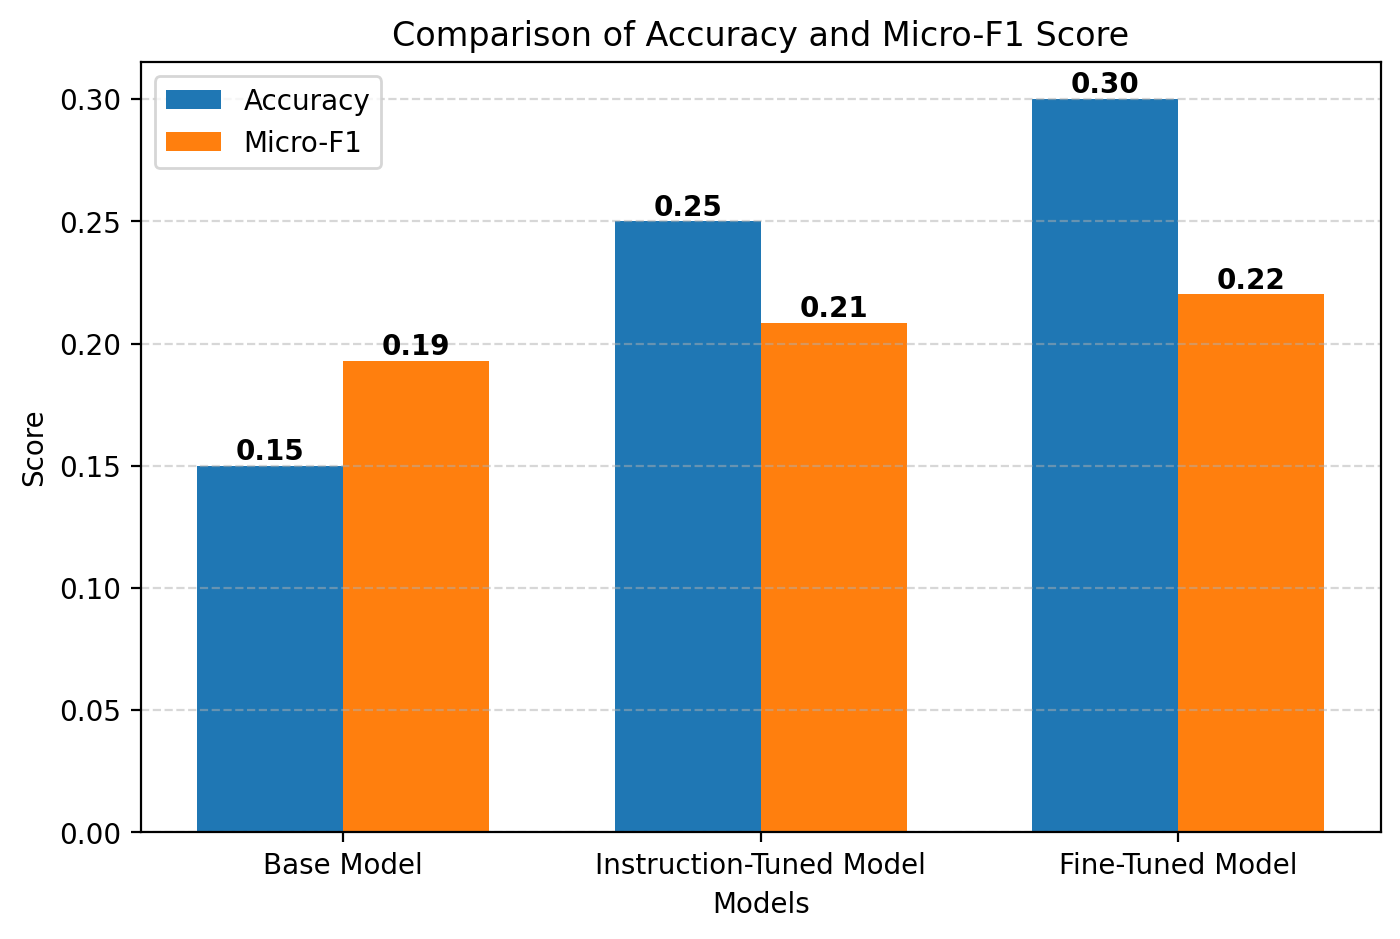

In [20]:
### Your Code
import matplotlib.pyplot as plt
import numpy as np


models = ["Base Model", "Instruction-Tuned Model", "Fine-Tuned Model"]


accuracy_scores = [0.15, 0.25, 0.30]
f1_scores = [0.1929, 0.2086, 0.2201]


x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
bars1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy')
bars2 = ax.bar(x + width/2, f1_scores, width, label='Micro-F1')


for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')


ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_title("Comparison of Accuracy and Micro-F1 Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle="--", alpha=0.5)


plt.show()

#### Q2.11: Analysis (10 pts)

Analyze the results and the reasons behind them.

```Your Answer Here```
<br>
Base Model:
<br>
In this model, accuracy=15%, F1-score = 0.19, precision is 0 for most categoriea, except for love where F1-score=1, th model performs somewhat better on joy with F1-score = 0.29 but fails on most other emotions. overall accuracy and F1-score indicating random like prediction. the base model lacks any training for emotion classification and thus relies on general language knowladge rather than structured emotion detection. it may certain keywords but can not effectively calssify emotion.
<br>
------------------------------------------------------------------------------------------
<br>
Instruct Tuned Model:
<br>
In this model, acuuracy improves to 25% and F1-score increases to 0.2085. The model performs better in sadness with recall = 50% but still struggles with joy and love. it correctly identifies anger with recall = 1, but this could be due to dataset imbalance.
I think since this model was trained using instruction tuning, it understands the concept of classification better. however it's not specifically fine tuned on this dataset, which limits its accuracy in certain emotions.
<br>
------------------------------------------------------------------------------------------
<br>
Fine Tuned Model with LoRA:
<br>
In this model accuracy reaches 30% and F1-score=0.2201, higher than instruct model. the model struggles with sadness and anger with F1-score = 0, it shows significant improvment in fear with F1-score = 0.67, indicating better recognition of this emotion. This modrl is fine-tuned directly on the emotion dataset, making it more effective, however the small dataset size limits its ability to generalize but we can see this model works better even than instruction tuning model. I think one reason about these masures is because of ability of model, model LlaMa 3 has 1B parameter and it is not very strong model, so I think this results are be expected.